### Cell 1 — Mount + imports + paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
OUT_DIR = BASE_DIR / "analysis" / "ct2dose_phase4_shoulder_aware_targeted_evaluation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VAL_MANIFEST = SPLIT_DIR / "train_pairs_3d_val_phase3_500.json"

TUNED_CKPT = CKPT_DIR / "lr5e4_base24_bs2_cont_to_50_best.pt"
MIXED_T010_CKPT = CKPT_DIR / "phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_best.pt"
MIXED_T015_CKPT = CKPT_DIR / "ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_best.pt"
SHOULDER_AWARE_CKPT = CKPT_DIR / "ct2dose_phase4_shoulder_aware_finetune_from_t015_lr1e4_ep12_b0p10_best.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

print("VAL_MANIFEST exists:", VAL_MANIFEST.exists())
print("TUNED_CKPT exists:", TUNED_CKPT.exists())
print("MIXED_T010_CKPT exists:", MIXED_T010_CKPT.exists())
print("MIXED_T015_CKPT exists:", MIXED_T015_CKPT.exists())
print("SHOULDER_AWARE_CKPT exists:", SHOULDER_AWARE_CKPT.exists())

Mounted at /content/drive
device: cuda
VAL_MANIFEST exists: True
TUNED_CKPT exists: True
MIXED_T010_CKPT exists: True
MIXED_T015_CKPT exists: True
SHOULDER_AWARE_CKPT exists: True


### Cell 2 — Optional title

In [3]:
from IPython.display import Markdown, display

display(Markdown(r"""
# CT-to-Dose Phase 4: Shoulder-Aware Targeted Evaluation
## Models
- tuned baseline
- mixed T=0.10, alpha=0.30, max_weight=3.0
- mixed T=0.15, alpha=0.30, max_weight=3.0
- shoulder-aware fine-tuned T=0.15, beta=0.10
"""))


# CT-to-Dose Phase 4: Shoulder-Aware Targeted Evaluation
## Models
- tuned baseline
- mixed T=0.10, alpha=0.30, max_weight=3.0
- mixed T=0.15, alpha=0.30, max_weight=3.0
- shoulder-aware fine-tuned T=0.15, beta=0.10


### Cell 3 — Dataset + model definitions

In [4]:
DOSE_SCALE = 1000.0
EPS = 1e-8

def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

def denormalize_ct(x_norm):
    return x_norm * (1500.0 + 1024.0) - 1024.0

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)
        x1 = torch.from_numpy(x1).unsqueeze(0)
        return x0, x1


class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])
        inp = torch.cat([xt, x0, t_map], dim=1)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)


@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### Cell 4 — Prediction helpers

In [5]:
@torch.no_grad()
def get_flow_prediction(model, dataset, idx, device, n_steps=30):
    x0, x1 = dataset[idx]
    x0_t = x0.unsqueeze(0).to(device)
    pred = euler_sample_flow_3d(model, x0_t, n_steps=n_steps).cpu().squeeze().numpy()

    ct_vol = x0.squeeze().numpy()
    gt_vol = x1.squeeze().numpy()
    return ct_vol, gt_vol, pred


def find_best_dose_slice_index(volume):
    slice_sums = volume.reshape(volume.shape[0], -1).sum(axis=1)
    return int(np.argmax(slice_sums))


def find_peak_xy(volume, slice_idx):
    slice_2d = volume[slice_idx]
    return np.unravel_index(np.argmax(slice_2d), slice_2d.shape)

### Cell 5 — Unified evaluation config

In [6]:
EVAL_THRESHOLD = 0.10
EVAL_THRESHOLD_MODE = "absolute"

print("Unified evaluation threshold:", EVAL_THRESHOLD)

Unified evaluation threshold: 0.1


### Cell 6 — Targeted evaluation metrics

In [7]:
def get_case_threshold(gt_vol, threshold=0.10, mode="absolute"):
    if mode == "absolute":
        T = float(threshold)
    elif mode == "relative_to_case_max":
        T = float(threshold) * float(gt_vol.max())
    else:
        raise ValueError(f"Unknown mode: {mode}")
    return max(T, 1e-8)


def compute_targeted_eval_metrics(gt_vol, pred_vol, threshold=0.10, mode="absolute"):
    T = get_case_threshold(gt_vol, threshold=threshold, mode=mode)

    abs_err = np.abs(pred_vol - gt_vol)
    sq_err = (pred_vol - gt_vol) ** 2

    weight = np.maximum(T, gt_vol) / T
    weighted_mse = float(np.mean(weight * sq_err))

    high_mask = gt_vol >= T
    outside_mask = gt_vol < T

    gt_max = float(gt_vol.max())
    peak_core_mask = gt_vol >= (0.8 * gt_max)
    peak_shoulder_mask = (gt_vol >= 0.3 * gt_max) & (gt_vol < 0.8 * gt_max)

    def safe_mean(arr):
        return float(np.mean(arr)) if arr.size > 0 else np.nan

    def safe_max(arr):
        return float(np.max(arr)) if arr.size > 0 else np.nan

    def safe_p95(arr):
        return float(np.percentile(arr, 95)) if arr.size > 0 else np.nan

    def safe_rel_err(gt_arr, pred_arr):
        denom = np.sum(np.abs(gt_arr))
        if gt_arr.size == 0 or denom <= 1e-8:
            return np.nan
        return float(100.0 * np.sum(np.abs(pred_arr - gt_arr)) / denom)

    return {
        "overall_mse": float(np.mean(sq_err)),
        "overall_mae": float(np.mean(abs_err)),
        "weighted_mse": weighted_mse,

        "high_mse": safe_mean(sq_err[high_mask]),
        "high_mae": safe_mean(abs_err[high_mask]),
        "high_rel_err_pct": safe_rel_err(gt_vol[high_mask], pred_vol[high_mask]),

        "outside_mse": safe_mean(sq_err[outside_mask]),
        "outside_mae": safe_mean(abs_err[outside_mask]),
        "outside_max_abs_error": safe_max(abs_err[outside_mask]),
        "outside_p95_abs_error": safe_p95(abs_err[outside_mask]),

        "peak_core_mae": safe_mean(abs_err[peak_core_mask]),
        "peak_shoulder_mae": safe_mean(abs_err[peak_shoulder_mask]),

        "threshold_used": T,
        "num_high_voxels": int(high_mask.sum()),
        "num_outside_voxels": int(outside_mask.sum()),
    }

### Cell 7 — Bone heuristic + structure features

In [8]:
def compute_bone_in_beam_heuristic(
    ct_vol_norm,
    gt_vol,
    threshold=0.10,
    band_halfwidth=1,
    bone_hu_threshold=300.0,
    min_bone_fraction=0.05
):
    slice_idx = find_best_dose_slice_index(gt_vol)
    peak_y, peak_x = find_peak_xy(gt_vol, slice_idx)

    gt_slice = gt_vol[slice_idx]
    ct_slice_hu = denormalize_ct(ct_vol_norm[slice_idx])

    y0 = max(0, peak_y - band_halfwidth)
    y1 = min(gt_slice.shape[0], peak_y + band_halfwidth + 1)

    dose_band = gt_slice[y0:y1, :]
    ct_band_hu = ct_slice_hu[y0:y1, :]

    relevant_mask = dose_band >= threshold

    if relevant_mask.sum() == 0:
        return {
            "bone_in_beam_candidate": False,
            "bone_fraction_in_relevant_band": 0.0,
            "max_hu_in_relevant_band": float(np.max(ct_band_hu)),
            "beam_slice_idx": int(slice_idx),
            "beam_peak_y": int(peak_y),
            "beam_peak_x": int(peak_x),
        }

    bone_mask = (ct_band_hu >= bone_hu_threshold) & relevant_mask
    bone_fraction = float(bone_mask.sum() / relevant_mask.sum())
    max_hu = float(np.max(ct_band_hu[relevant_mask]))

    return {
        "bone_in_beam_candidate": bone_fraction >= min_bone_fraction,
        "bone_fraction_in_relevant_band": bone_fraction,
        "max_hu_in_relevant_band": max_hu,
        "beam_slice_idx": int(slice_idx),
        "beam_peak_y": int(peak_y),
        "beam_peak_x": int(peak_x),
    }


def compute_case_structure_features(ct_vol_norm, gt_vol, threshold=0.10):
    slice_idx = find_best_dose_slice_index(gt_vol)
    gt_slice = gt_vol[slice_idx]
    relevant_mask = gt_slice >= threshold
    ct_slice_hu = denormalize_ct(ct_vol_norm[slice_idx])

    return {
        "gt_max": float(gt_vol.max()),
        "dose_sum_slice": float(np.sum(gt_slice)),
        "relevant_fraction_in_slice": float(np.mean(relevant_mask)),
        "ct_hu_mean_relevant": float(np.mean(ct_slice_hu[relevant_mask])) if relevant_mask.sum() > 0 else np.nan,
        "ct_hu_std_relevant": float(np.std(ct_slice_hu[relevant_mask])) if relevant_mask.sum() > 0 else np.nan,
    }

### Cell 8 — Load dataset and models

In [9]:
val_dataset_3d = CubePair3DDataset(VAL_MANIFEST, dose_scale=DOSE_SCALE)

model_specs = {
    "tuned": TUNED_CKPT,
    "mixed_T010_a030_mw3": MIXED_T010_CKPT,
    "mixed_T015_a030_mw3": MIXED_T015_CKPT,
    "shoulder_aware_T015_b0p10": SHOULDER_AWARE_CKPT,
}

models = {}

for model_name, ckpt_path in model_specs.items():
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=24).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    models[model_name] = model
    print("Loaded:", model_name, "from", ckpt_path)

print("Validation samples:", len(val_dataset_3d))

Loaded: tuned from /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/lr5e4_base24_bs2_cont_to_50_best.pt
Loaded: mixed_T010_a030_mw3 from /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_best.pt
Loaded: mixed_T015_a030_mw3 from /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_best.pt
Loaded: shoulder_aware_T015_b0p10 from /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase4_shoulder_aware_finetune_from_t015_lr1e4_ep12_b0p10_best.pt
Validation samples: 500


### Cell 9 — Build full casewise table

In [10]:
all_rows = []

for idx in range(len(val_dataset_3d)):
    ct_vol, gt_vol, _ = get_flow_prediction(models["tuned"], val_dataset_3d, idx, device, n_steps=30)

    bone_info = compute_bone_in_beam_heuristic(
        ct_vol_norm=ct_vol,
        gt_vol=gt_vol,
        threshold=EVAL_THRESHOLD,
        band_halfwidth=1,
        bone_hu_threshold=300.0,
        min_bone_fraction=0.05
    )

    structure_info = compute_case_structure_features(
        ct_vol_norm=ct_vol,
        gt_vol=gt_vol,
        threshold=EVAL_THRESHOLD
    )

    for model_name, model in models.items():
        _, _, pred_vol = get_flow_prediction(model, val_dataset_3d, idx, device, n_steps=30)

        metrics = compute_targeted_eval_metrics(
            gt_vol,
            pred_vol,
            threshold=EVAL_THRESHOLD,
            mode=EVAL_THRESHOLD_MODE
        )

        all_rows.append({
            "sample_idx": idx,
            "model": model_name,
            **bone_info,
            **structure_info,
            **metrics
        })

comparison_df = pd.DataFrame(all_rows)

comparison_csv = OUT_DIR / "ct2dose_shoulder_aware_targeted_casewise_metrics.csv"
comparison_df.to_csv(comparison_csv, index=False)

print("Saved:", comparison_csv)
display(comparison_df.head())

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/ct2dose_shoulder_aware_targeted_casewise_metrics.csv


,sample_idx,model,bone_in_beam_candidate,bone_fraction_in_relevant_band,max_hu_in_relevant_band,beam_slice_idx,beam_peak_y,beam_peak_x,gt_max,dose_sum_slice,...,high_rel_err_pct,outside_mse,outside_mae,outside_max_abs_error,outside_p95_abs_error,peak_core_mae,peak_shoulder_mae,threshold_used,num_high_voxels,num_outside_voxels
0,0,tuned,True,0.184211,830.923096,16,16,0,3.831937,93.760818,...,2.674569,0.000009,0.002039,0.033027,0.005827,0.116217,0.040665,0.1,4792,27976
1,0,mixed_T010_a030_mw3,True,0.184211,830.923096,16,16,0,3.831937,93.760818,...,3.067804,0.000010,0.002213,0.030373,0.006509,0.016567,0.026900,0.1,4792,27976
2,0,mixed_T015_a030_mw3,True,0.184211,830.923096,16,16,0,3.831937,93.760818,...,4.279728,0.000010,0.002287,0.029703,0.006291,0.134311,0.034756,0.1,4792,27976
3,0,shoulder_aware_T015_b0p10,True,0.184211,830.923096,16,16,0,3.831937,93.760818,...,3.405483,0.000010,0.002296,0.032110,0.006151,0.129659,0.039751,0.1,4792,27976
4,1,tuned,False,0.000000,48.529053,16,16,0,3.443971,89.784882,...,2.663460,0.000019,0.002665,0.048240,0.009107,0.119658,0.050966,0.1,4218,28550


### Cell 10 — Overall summary

In [11]:
summary_df = comparison_df.groupby("model").agg({
    "overall_mse": "mean",
    "overall_mae": "mean",
    "weighted_mse": "mean",
    "high_mse": "mean",
    "high_mae": "mean",
    "high_rel_err_pct": "mean",
    "outside_mse": "mean",
    "outside_mae": "mean",
    "outside_max_abs_error": "mean",
    "outside_p95_abs_error": "mean",
    "peak_core_mae": "mean",
    "peak_shoulder_mae": "mean",
}).reset_index()

summary_csv = OUT_DIR / "ct2dose_shoulder_aware_targeted_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print("Saved:", summary_csv)
display(summary_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/ct2dose_shoulder_aware_targeted_summary.csv


,model,overall_mse,overall_mae,weighted_mse,high_mse,high_mae,high_rel_err_pct,outside_mse,outside_mae,outside_max_abs_error,outside_p95_abs_error,peak_core_mae,peak_shoulder_mae
0,mixed_T010_a030_mw3,0.000018,0.002735,0.000036,0.000051,0.004753,2.769959,0.000014,0.002484,0.034395,0.007353,0.050830,0.020989
1,mixed_T015_a030_mw3,0.000018,0.002737,0.000036,0.000052,0.004922,2.843983,0.000013,0.002441,0.035028,0.007104,0.047258,0.019713
2,shoulder_aware_T015_b0p10,0.000016,0.002683,0.000028,0.000039,0.004179,2.425058,0.000013,0.002488,0.036348,0.007017,0.036051,0.015444
3,tuned,0.000017,0.002662,0.000038,0.000052,0.004830,2.802542,0.000013,0.002382,0.032495,0.006932,0.047654,0.022622


### Cell 11 — Bone / non-bone subset summary

In [12]:
bone_subset_df = comparison_df[comparison_df["bone_in_beam_candidate"] == True].copy()
nonbone_subset_df = comparison_df[comparison_df["bone_in_beam_candidate"] == False].copy()

def summarize_subset(df, tag):
    if len(df) == 0:
        return pd.DataFrame()

    out = df.groupby("model").agg({
        "overall_mae": "mean",
        "weighted_mse": "mean",
        "high_mae": "mean",
        "outside_mae": "mean",
        "outside_max_abs_error": "mean",
        "peak_core_mae": "mean",
        "peak_shoulder_mae": "mean",
    }).reset_index()
    out["subset"] = tag
    return out

bone_summary_df = summarize_subset(bone_subset_df, "bone_in_beam_candidate")
nonbone_summary_df = summarize_subset(nonbone_subset_df, "non_bone_candidate")
subset_summary_df = pd.concat([bone_summary_df, nonbone_summary_df], axis=0, ignore_index=True)

subset_summary_csv = OUT_DIR / "ct2dose_shoulder_aware_targeted_subset_summary.csv"
subset_summary_df.to_csv(subset_summary_csv, index=False)

print("Bone-in-beam candidate count:", bone_subset_df["sample_idx"].nunique())
print("Non-bone candidate count:", nonbone_subset_df["sample_idx"].nunique())
print("Saved:", subset_summary_csv)
display(subset_summary_df)

Bone-in-beam candidate count: 144
Non-bone candidate count: 356
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/ct2dose_shoulder_aware_targeted_subset_summary.csv


,model,overall_mae,weighted_mse,high_mae,outside_mae,outside_max_abs_error,peak_core_mae,peak_shoulder_mae,subset
0,mixed_T010_a030_mw3,0.002843,0.000043,0.004896,0.002552,0.036110,0.049826,0.022833,bone_in_beam_candidate
1,mixed_T015_a030_mw3,0.002923,0.000046,0.005538,0.002534,0.036168,0.051169,0.023038,bone_in_beam_candidate
2,shoulder_aware_T015_b0p10,0.002849,0.000036,0.004512,0.002609,0.037125,0.040518,0.017848,bone_in_beam_candidate
3,tuned,0.002786,0.000048,0.005103,0.002453,0.033667,0.050952,0.025849,bone_in_beam_candidate
4,mixed_T010_a030_mw3,0.002691,0.000033,0.004695,0.002457,0.033702,0.051236,0.020243,non_bone_candidate
5,mixed_T015_a030_mw3,0.002661,0.000031,0.004673,0.002403,0.034567,0.045676,0.018369,non_bone_candidate
6,shoulder_aware_T015_b0p10,0.002616,0.000025,0.004044,0.002440,0.036033,0.034243,0.014471,non_bone_candidate
7,tuned,0.002612,0.000033,0.004719,0.002353,0.032021,0.046320,0.021317,non_bone_candidate


### Cell 12 — Winner counts

In [13]:
metric_cols = [
    "overall_mae",
    "weighted_mse",
    "high_mae",
    "outside_mae",
    "outside_max_abs_error",
    "peak_core_mae",
    "peak_shoulder_mae",
]

winner_rows = []

for metric in metric_cols:
    pivot = comparison_df.pivot(index="sample_idx", columns="model", values=metric)
    winner = pivot.idxmin(axis=1).value_counts()

    for model_name, count in winner.items():
        winner_rows.append({
            "metric": metric,
            "winner_model": model_name,
            "num_cases_won": int(count)
        })

winner_count_df = pd.DataFrame(winner_rows)

winner_count_csv = OUT_DIR / "ct2dose_shoulder_aware_targeted_winner_counts.csv"
winner_count_df.to_csv(winner_count_csv, index=False)

print("Saved:", winner_count_csv)
display(winner_count_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/ct2dose_shoulder_aware_targeted_winner_counts.csv


,metric,winner_model,num_cases_won
0,overall_mae,tuned,172
1,overall_mae,shoulder_aware_T015_b0p10,129
2,overall_mae,mixed_T015_a030_mw3,106
3,overall_mae,mixed_T010_a030_mw3,93
4,weighted_mse,shoulder_aware_T015_b0p10,214
5,weighted_mse,tuned,103
6,weighted_mse,mixed_T010_a030_mw3,96
7,weighted_mse,mixed_T015_a030_mw3,87
8,high_mae,shoulder_aware_T015_b0p10,223
9,high_mae,mixed_T010_a030_mw3,120


### Cell 13 — Winner counts by subset

In [14]:
subset_rows = []

case_info_df = comparison_df[comparison_df["model"] == "tuned"][["sample_idx", "bone_in_beam_candidate"]].copy()

for subset_value, subset_name in [(True, "bone_in_beam_candidate"), (False, "non_bone_candidate")]:
    sub_case_ids = case_info_df[case_info_df["bone_in_beam_candidate"] == subset_value]["sample_idx"].tolist()
    sub_df = comparison_df[comparison_df["sample_idx"].isin(sub_case_ids)].copy()

    for metric in metric_cols:
        pivot = sub_df.pivot(index="sample_idx", columns="model", values=metric)
        winner = pivot.idxmin(axis=1).value_counts()

        for model_name, count in winner.items():
            subset_rows.append({
                "subset": subset_name,
                "metric": metric,
                "winner_model": model_name,
                "num_cases_won": int(count)
            })

subset_winner_df = pd.DataFrame(subset_rows)

subset_winner_csv = OUT_DIR / "ct2dose_shoulder_aware_targeted_subset_winner_counts.csv"
subset_winner_df.to_csv(subset_winner_csv, index=False)

print("Saved:", subset_winner_csv)
display(subset_winner_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/ct2dose_shoulder_aware_targeted_subset_winner_counts.csv


,subset,metric,winner_model,num_cases_won
0,bone_in_beam_candidate,overall_mae,tuned,51
1,bone_in_beam_candidate,overall_mae,shoulder_aware_T015_b0p10,38
2,bone_in_beam_candidate,overall_mae,mixed_T010_a030_mw3,33
3,bone_in_beam_candidate,overall_mae,mixed_T015_a030_mw3,22
4,bone_in_beam_candidate,weighted_mse,shoulder_aware_T015_b0p10,66
5,bone_in_beam_candidate,weighted_mse,mixed_T010_a030_mw3,32
6,bone_in_beam_candidate,weighted_mse,tuned,27
7,bone_in_beam_candidate,weighted_mse,mixed_T015_a030_mw3,19
8,bone_in_beam_candidate,high_mae,shoulder_aware_T015_b0p10,60
9,bone_in_beam_candidate,high_mae,mixed_T010_a030_mw3,41


### Cell 14 — Direct comparison: shoulder-aware vs plain mixed T0.15

In [15]:
pivot_weighted = comparison_df.pivot(index="sample_idx", columns="model", values="weighted_mse").reset_index()
pivot_high = comparison_df.pivot(index="sample_idx", columns="model", values="high_mae").reset_index()
pivot_overall = comparison_df.pivot(index="sample_idx", columns="model", values="overall_mae").reset_index()
pivot_core = comparison_df.pivot(index="sample_idx", columns="model", values="peak_core_mae").reset_index()
pivot_shoulder = comparison_df.pivot(index="sample_idx", columns="model", values="peak_shoulder_mae").reset_index()

direct_compare_df = pivot_weighted.merge(pivot_high, on="sample_idx", suffixes=("_weighted", "_high"))
direct_compare_df = direct_compare_df.merge(pivot_overall, on="sample_idx", suffixes=("", "_overall"))
direct_compare_df = direct_compare_df.merge(pivot_core, on="sample_idx", suffixes=("", "_core"))
direct_compare_df = direct_compare_df.merge(pivot_shoulder, on="sample_idx", suffixes=("", "_shoulder"))

direct_compare_df = direct_compare_df.rename(columns={
    "mixed_T015_a030_mw3_weighted": "weighted_t015",
    "shoulder_aware_T015_b0p10_weighted": "weighted_shoulder",
    "mixed_T015_a030_mw3_high": "high_t015",
    "shoulder_aware_T015_b0p10_high": "high_shoulder",
    "mixed_T015_a030_mw3": "overall_t015",
    "shoulder_aware_T015_b0p10": "overall_shoulder",
    "mixed_T015_a030_mw3_core": "core_t015",
    "shoulder_aware_T015_b0p10_core": "core_shoulder",
    "mixed_T015_a030_mw3_shoulder": "shoulder_t015",
    "shoulder_aware_T015_b0p10_shoulder": "shoulder_shoulder",
})

direct_compare_df = direct_compare_df.merge(case_info_df, on="sample_idx", how="left")

direct_compare_df["delta_weighted_shoulder_vs_t015"] = direct_compare_df["weighted_shoulder"] - direct_compare_df["weighted_t015"]
direct_compare_df["delta_high_shoulder_vs_t015"] = direct_compare_df["high_shoulder"] - direct_compare_df["high_t015"]
direct_compare_df["delta_overall_shoulder_vs_t015"] = direct_compare_df["overall_shoulder"] - direct_compare_df["overall_t015"]
direct_compare_df["delta_core_shoulder_vs_t015"] = direct_compare_df["core_shoulder"] - direct_compare_df["core_t015"]
direct_compare_df["delta_shoulder_shoulder_vs_t015"] = direct_compare_df["shoulder_shoulder"] - direct_compare_df["shoulder_t015"]

direct_compare_csv = OUT_DIR / "ct2dose_shoulder_aware_vs_t015_direct_compare.csv"
direct_compare_df.to_csv(direct_compare_csv, index=False)

print("Saved:", direct_compare_csv)
display(direct_compare_df.head())

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/ct2dose_shoulder_aware_vs_t015_direct_compare.csv


,sample_idx,mixed_T010_a030_mw3_weighted,weighted_t015,weighted_shoulder,tuned_weighted,mixed_T010_a030_mw3_high,high_t015,high_shoulder,tuned_high,mixed_T010_a030_mw3,...,mixed_T010_a030_mw3_shoulder,shoulder_t015,shoulder_shoulder,tuned_shoulder,bone_in_beam_candidate,delta_weighted_shoulder_vs_t015,delta_high_shoulder_vs_t015,delta_overall_shoulder_vs_t015,delta_core_shoulder_vs_t015,delta_shoulder_shoulder_vs_t015
0,0,0.000043,0.000082,0.000073,0.000064,0.005744,0.008013,0.006376,0.005007,0.002729,...,0.026900,0.034756,0.039751,0.040665,True,-9.216703e-06,-0.001637,-0.000232,-0.004652,0.004995
1,1,0.000051,0.000043,0.000035,0.000084,0.004500,0.004337,0.003577,0.004855,0.003210,...,0.030684,0.026881,0.020825,0.050966,False,-8.717212e-06,-0.000760,0.000100,-0.014100,-0.006056
2,2,0.000027,0.000025,0.000025,0.000023,0.003901,0.004991,0.004244,0.004345,0.003304,...,0.012451,0.014008,0.005508,0.010697,True,-1.865865e-07,-0.000748,0.000310,0.000046,-0.008500
3,3,0.000159,0.000113,0.000111,0.000103,0.008657,0.011287,0.008943,0.008164,0.003230,...,0.072801,0.040793,0.046377,0.051690,True,-2.548491e-06,-0.002344,-0.000208,0.022535,0.005584
4,4,0.000034,0.000017,0.000014,0.000023,0.005940,0.004073,0.002845,0.004382,0.002824,...,0.021754,0.011315,0.008920,0.013357,False,-2.829760e-06,-0.001228,-0.000114,0.020478,-0.002395


### Cell 15 — Compact summary focused on shoulder-aware vs T0.15

In [16]:
compact_rows = []

for subset_value, subset_name in [(None, "all_cases"), (True, "bone_in_beam"), (False, "non_bone")]:
    if subset_value is None:
        sub = direct_compare_df.copy()
    else:
        sub = direct_compare_df[direct_compare_df["bone_in_beam_candidate"] == subset_value].copy()

    compact_rows.append({
        "subset": subset_name,
        "num_cases": len(sub),
        "mean_delta_weighted_shoulder_vs_t015": float(np.mean(sub["delta_weighted_shoulder_vs_t015"])),
        "mean_delta_high_shoulder_vs_t015": float(np.mean(sub["delta_high_shoulder_vs_t015"])),
        "mean_delta_overall_shoulder_vs_t015": float(np.mean(sub["delta_overall_shoulder_vs_t015"])),
        "mean_delta_core_shoulder_vs_t015": float(np.mean(sub["delta_core_shoulder_vs_t015"])),
        "mean_delta_shoulder_shoulder_vs_t015": float(np.mean(sub["delta_shoulder_shoulder_vs_t015"])),
    })

compact_summary_df = pd.DataFrame(compact_rows)

compact_summary_csv = OUT_DIR / "ct2dose_shoulder_aware_targeted_compact_summary.csv"
compact_summary_df.to_csv(compact_summary_csv, index=False)

print("Saved:", compact_summary_csv)
display(compact_summary_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/ct2dose_shoulder_aware_targeted_compact_summary.csv


,subset,num_cases,mean_delta_weighted_shoulder_vs_t015,mean_delta_high_shoulder_vs_t015,mean_delta_overall_shoulder_vs_t015,mean_delta_core_shoulder_vs_t015,mean_delta_shoulder_shoulder_vs_t015
0,all_cases,500,-0.000008,-0.000744,-0.000054,-0.011207,-0.004270
1,bone_in_beam,144,-0.000011,-0.001026,-0.000075,-0.010651,-0.005189
2,non_bone,356,-0.000006,-0.000629,-0.000046,-0.011432,-0.003898


### Cell 16 — Representative cases from tuned ranking

In [17]:
tuned_only = comparison_df[comparison_df["model"] == "tuned"].copy()
tuned_only = tuned_only.sort_values("weighted_mse").reset_index(drop=True)

best_case_idx = int(tuned_only.iloc[0]["sample_idx"])
typical_case_idx = int(tuned_only.iloc[len(tuned_only) // 2]["sample_idx"])
worst_case_idx = int(tuned_only.iloc[-1]["sample_idx"])

print("best_case_idx   =", best_case_idx)
print("typical_case_idx=", typical_case_idx)
print("worst_case_idx  =", worst_case_idx)

best_case_idx   = 496
typical_case_idx= 491
worst_case_idx  = 221


### Cell 17 — Same-scale representative-case helper

In [18]:
def save_same_scale_compare_for_case(case_idx, out_path):
    ct_vol, gt_vol, tuned_pred = get_flow_prediction(models["tuned"], val_dataset_3d, case_idx, device, n_steps=30)
    _, _, mixed010_pred = get_flow_prediction(models["mixed_T010_a030_mw3"], val_dataset_3d, case_idx, device, n_steps=30)
    _, _, mixed015_pred = get_flow_prediction(models["mixed_T015_a030_mw3"], val_dataset_3d, case_idx, device, n_steps=30)
    _, _, shoulder_pred = get_flow_prediction(models["shoulder_aware_T015_b0p10"], val_dataset_3d, case_idx, device, n_steps=30)

    slice_idx = find_best_dose_slice_index(gt_vol)

    gt_slice = gt_vol[slice_idx]
    tuned_slice = tuned_pred[slice_idx]
    mixed010_slice = mixed010_pred[slice_idx]
    mixed015_slice = mixed015_pred[slice_idx]
    shoulder_slice = shoulder_pred[slice_idx]

    tuned_abs = np.abs(tuned_slice - gt_slice)
    mixed010_abs = np.abs(mixed010_slice - gt_slice)
    mixed015_abs = np.abs(mixed015_slice - gt_slice)
    shoulder_abs = np.abs(shoulder_slice - gt_slice)

    shared_vmax = max(
        float(tuned_abs.max()),
        float(mixed010_abs.max()),
        float(mixed015_abs.max()),
        float(shoulder_abs.max())
    )

    fig, axes = plt.subplots(1, 9, figsize=(34, 4))

    gt_vmin = float(gt_slice.min())
    gt_vmax = float(gt_slice.max())

    im0 = axes[0].imshow(gt_slice, cmap="hot", vmin=gt_vmin, vmax=gt_vmax)
    axes[0].set_title("Ground Truth")
    axes[0].axis("off")

    im1 = axes[1].imshow(tuned_slice, cmap="hot", vmin=gt_vmin, vmax=gt_vmax)
    axes[1].set_title("Tuned")
    axes[1].axis("off")

    im2 = axes[2].imshow(mixed010_slice, cmap="hot", vmin=gt_vmin, vmax=gt_vmax)
    axes[2].set_title("Mixed T0.10")
    axes[2].axis("off")

    im3 = axes[3].imshow(mixed015_slice, cmap="hot", vmin=gt_vmin, vmax=gt_vmax)
    axes[3].set_title("Mixed T0.15")
    axes[3].axis("off")

    im4 = axes[4].imshow(shoulder_slice, cmap="hot", vmin=gt_vmin, vmax=gt_vmax)
    axes[4].set_title("Shoulder-aware T0.15")
    axes[4].axis("off")

    im5 = axes[5].imshow(tuned_abs, cmap="hot", vmin=0.0, vmax=shared_vmax)
    axes[5].set_title("Tuned Abs Diff")
    axes[5].axis("off")

    im6 = axes[6].imshow(mixed010_abs, cmap="hot", vmin=0.0, vmax=shared_vmax)
    axes[6].set_title("Mixed T0.10 Abs Diff")
    axes[6].axis("off")

    im7 = axes[7].imshow(mixed015_abs, cmap="hot", vmin=0.0, vmax=shared_vmax)
    axes[7].set_title("Mixed T0.15 Abs Diff")
    axes[7].axis("off")

    im8 = axes[8].imshow(shoulder_abs, cmap="hot", vmin=0.0, vmax=shared_vmax)
    axes[8].set_title("Shoulder-aware T0.15 Abs Diff")
    axes[8].axis("off")

    cbar1 = fig.colorbar(im4, ax=axes[:5], fraction=0.02, pad=0.01)
    cbar1.set_label("Dose")
    cbar2 = fig.colorbar(im8, ax=axes[5:], fraction=0.02, pad=0.01)
    cbar2.set_label("Absolute difference")

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

### Cell 18 — Save representative figures

/tmp/ipykernel_624/832708128.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


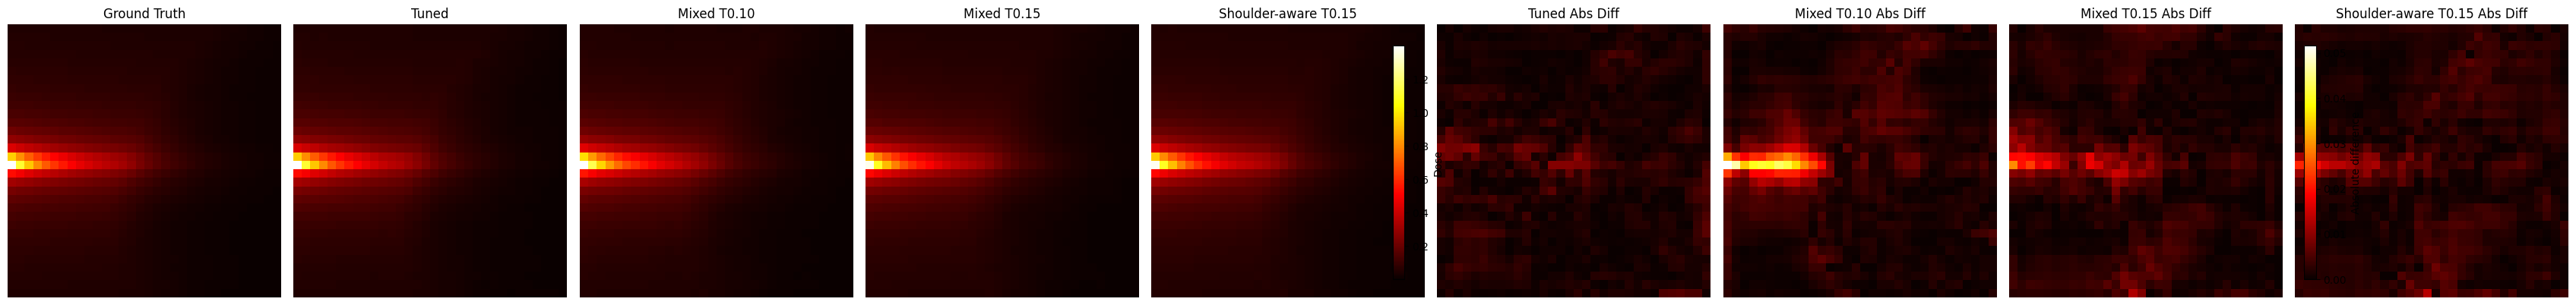

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/representative_cases/case496_same_scale_compare.png


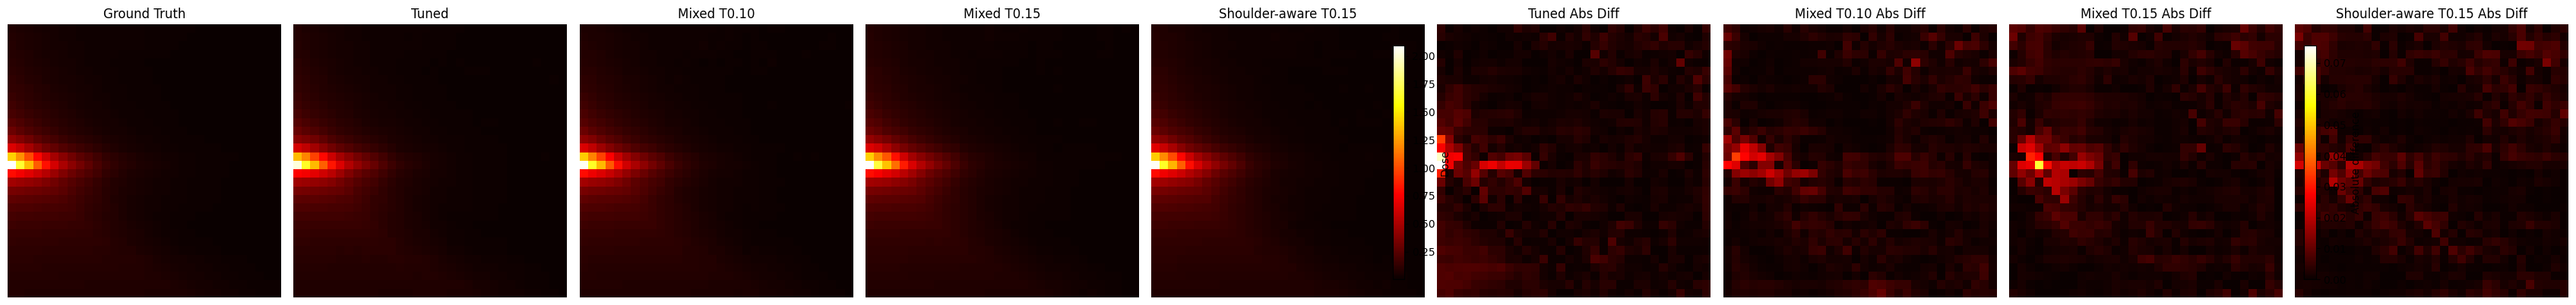

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/representative_cases/case491_same_scale_compare.png


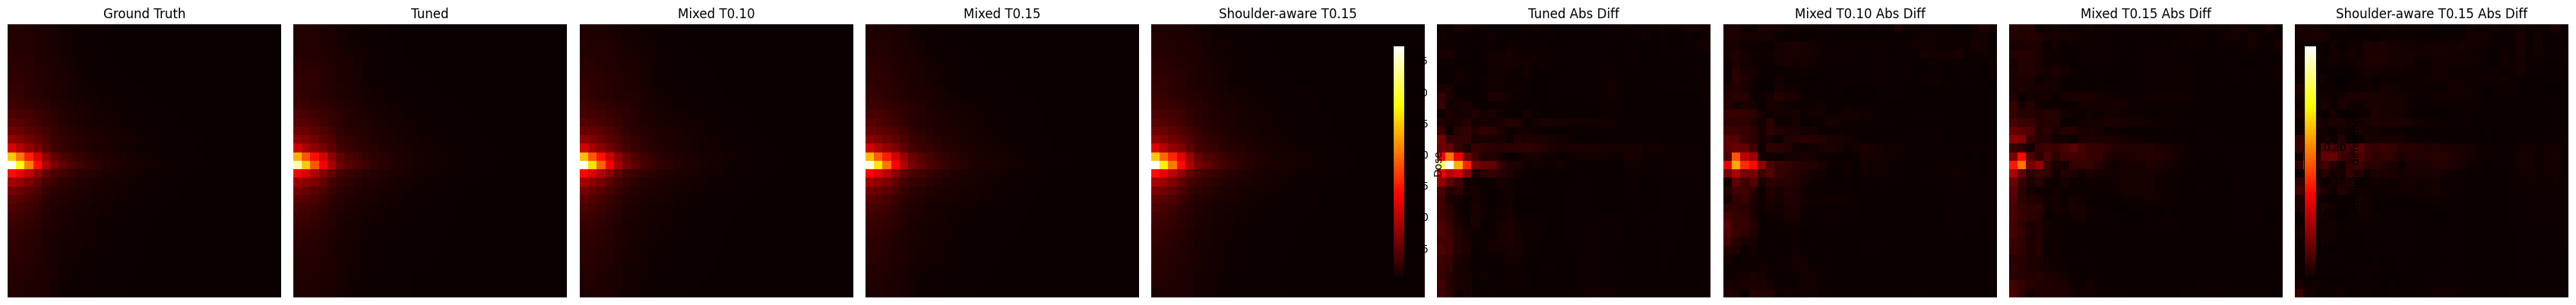

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/representative_cases/case221_same_scale_compare.png


In [19]:
rep_dir = OUT_DIR / "representative_cases"
rep_dir.mkdir(parents=True, exist_ok=True)

best_img = rep_dir / f"case{best_case_idx}_same_scale_compare.png"
typical_img = rep_dir / f"case{typical_case_idx}_same_scale_compare.png"
worst_img = rep_dir / f"case{worst_case_idx}_same_scale_compare.png"

save_same_scale_compare_for_case(best_case_idx, best_img)
print("Saved:", best_img)

save_same_scale_compare_for_case(typical_case_idx, typical_img)
print("Saved:", typical_img)

save_same_scale_compare_for_case(worst_case_idx, worst_img)
print("Saved:", worst_img)

### Cell 19 — Trello-ready summary table

In [20]:
trello_table = summary_df[
    [
        "model",
        "overall_mae",
        "weighted_mse",
        "high_mae",
        "outside_mae",
        "outside_max_abs_error",
        "peak_core_mae",
        "peak_shoulder_mae",
    ]
].copy()

order = ["tuned", "mixed_T010_a030_mw3", "mixed_T015_a030_mw3", "shoulder_aware_T015_b0p10"]
trello_table["model"] = pd.Categorical(trello_table["model"], categories=order, ordered=True)
trello_table = trello_table.sort_values("model").reset_index(drop=True)

trello_table_fmt = trello_table.copy()
for col in trello_table_fmt.columns:
    if col != "model":
        trello_table_fmt[col] = trello_table_fmt[col].map(lambda x: f"{x:.6f}")

trello_csv = OUT_DIR / "ct2dose_shoulder_aware_targeted_trello_summary.csv"
trello_table_fmt.to_csv(trello_csv, index=False)

print("Saved:", trello_csv)
display(trello_table_fmt)
print(trello_table_fmt.to_markdown(index=False))

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/ct2dose_shoulder_aware_targeted_trello_summary.csv


,model,overall_mae,weighted_mse,high_mae,outside_mae,outside_max_abs_error,peak_core_mae,peak_shoulder_mae
0,tuned,0.002662,0.000038,0.004830,0.002382,0.032495,0.047654,0.022622
1,mixed_T010_a030_mw3,0.002735,0.000036,0.004753,0.002484,0.034395,0.050830,0.020989
2,mixed_T015_a030_mw3,0.002737,0.000036,0.004922,0.002441,0.035028,0.047258,0.019713
3,shoulder_aware_T015_b0p10,0.002683,0.000028,0.004179,0.002488,0.036348,0.036051,0.015444


| model                     |   overall_mae |   weighted_mse |   high_mae |   outside_mae |   outside_max_abs_error |   peak_core_mae |   peak_shoulder_mae |
|:--------------------------|--------------:|---------------:|-----------:|--------------:|------------------------:|----------------:|--------------------:|
| tuned                     |      0.002662 |        3.8e-05 |   0.00483  |      0.002382 |                0.032495 |        0.047654 |            0.022622 |
| mixed_T010_a030_mw3       |      0.002735 |        3.6e-05 |   0.004753 |      0.002484 |                0.034395 |        0.05083  |            0.020989 |
| mixed_T015_a030_mw3       |      0.002737 |        3.6e-05 |   0.004922 |      0.002441 |                0.035028 |        0.047258 |            0.019713 |
| shoulder_aware_T015_b0p10 |      0.002683 |        2.8e-05 |   0.004179 |      0.002488 |                0.036348 |        0.036051 |            0.015444 |


### Cell 20 — Optional scatter: shoulder-aware advantage vs CT heterogeneity

Columns in direct_compare_plot_df:
['sample_idx', 'mixed_T010_a030_mw3_weighted', 'weighted_t015', 'weighted_shoulder', 'tuned_weighted', 'mixed_T010_a030_mw3_high', 'high_t015', 'high_shoulder', 'tuned_high', 'mixed_T010_a030_mw3', 'overall_t015', 'overall_shoulder', 'tuned', 'mixed_T010_a030_mw3_core', 'core_t015', 'core_shoulder', 'tuned_core', 'mixed_T010_a030_mw3_shoulder', 'shoulder_t015', 'shoulder_shoulder', 'tuned_shoulder', 'bone_in_beam_candidate_x', 'delta_weighted_shoulder_vs_t015', 'delta_high_shoulder_vs_t015', 'delta_overall_shoulder_vs_t015', 'delta_core_shoulder_vs_t015', 'delta_shoulder_shoulder_vs_t015', 'bone_in_beam_candidate_y', 'bone_fraction_in_relevant_band', 'max_hu_in_relevant_band', 'gt_max', 'dose_sum_slice', 'relevant_fraction_in_slice', 'ct_hu_mean_relevant', 'ct_hu_std_relevant']


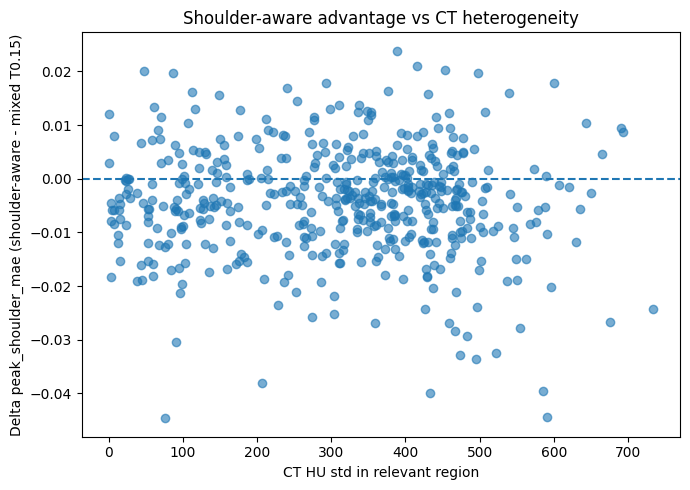

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/ct2dose_shoulder_aware_vs_t015_scatter_ctstd.png


In [21]:
# richer case info from tuned rows
case_info_rich_df = comparison_df[comparison_df["model"] == "tuned"][
    [
        "sample_idx",
        "bone_in_beam_candidate",
        "bone_fraction_in_relevant_band",
        "max_hu_in_relevant_band",
        "gt_max",
        "dose_sum_slice",
        "relevant_fraction_in_slice",
        "ct_hu_mean_relevant",
        "ct_hu_std_relevant",
    ]
].copy()

# merge richer info into direct_compare_df
direct_compare_plot_df = direct_compare_df.merge(
    case_info_rich_df,
    on="sample_idx",
    how="left"
)

print("Columns in direct_compare_plot_df:")
print(direct_compare_plot_df.columns.tolist())

plt.figure(figsize=(7,5))
plt.scatter(
    direct_compare_plot_df["ct_hu_std_relevant"],
    direct_compare_plot_df["delta_shoulder_shoulder_vs_t015"],
    alpha=0.6
)
plt.axhline(0, linestyle="--")
plt.xlabel("CT HU std in relevant region")
plt.ylabel("Delta peak_shoulder_mae (shoulder-aware - mixed T0.15)")
plt.title("Shoulder-aware advantage vs CT heterogeneity")
plt.tight_layout()

scatter_path = OUT_DIR / "ct2dose_shoulder_aware_vs_t015_scatter_ctstd.png"
plt.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", scatter_path)

In [22]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
ANALYSIS_DIR = BASE_DIR / "analysis" / "ct2dose_phase4_shoulder_aware_targeted_evaluation"

summary_csv = ANALYSIS_DIR / "ct2dose_shoulder_aware_targeted_summary.csv"

summary_df = pd.read_csv(summary_csv)

# 只保留最终要汇报的 4 个模型
keep_models = [
    "tuned",
    "mixed_T010_a030_mw3",
    "mixed_T015_a030_mw3",
    "shoulder_aware_T015_b0p10",
]

# 只保留最终表格需要的列
final_cols = [
    "model",
    "overall_mae",
    "weighted_mse",
    "high_mae",
    "outside_mae",
    "peak_core_mae",
    "peak_shoulder_mae",
]

final_comparison_df = summary_df[summary_df["model"].isin(keep_models)][final_cols].copy()

# 调整模型显示顺序
final_comparison_df["model"] = pd.Categorical(
    final_comparison_df["model"],
    categories=keep_models,
    ordered=True
)
final_comparison_df = final_comparison_df.sort_values("model").reset_index(drop=True)

# 可选：把模型名改得更适合给老师看
name_map = {
    "tuned": "Tuned",
    "mixed_T010_a030_mw3": "Mixed T0.10",
    "mixed_T015_a030_mw3": "Mixed T0.15",
    "shoulder_aware_T015_b0p10": "Shoulder-aware T0.15",
}
final_comparison_df["model"] = final_comparison_df["model"].map(name_map)

# 保存原始数值版 CSV
out_csv = ANALYSIS_DIR / "ct2dose_final_comparison_table_card30.csv"
final_comparison_df.to_csv(out_csv, index=False)

print("Saved CSV:", out_csv)
display(final_comparison_df)

Saved CSV: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/ct2dose_final_comparison_table_card30.csv


,model,overall_mae,weighted_mse,high_mae,outside_mae,peak_core_mae,peak_shoulder_mae
0,Tuned,0.002662,0.000038,0.004830,0.002382,0.047654,0.022622
1,Mixed T0.10,0.002735,0.000036,0.004753,0.002484,0.050830,0.020989
2,Mixed T0.15,0.002737,0.000036,0.004922,0.002441,0.047258,0.019713
3,Shoulder-aware T0.15,0.002683,0.000028,0.004179,0.002488,0.036051,0.015444


In [23]:
final_comparison_fmt = final_comparison_df.copy()

for col in final_comparison_fmt.columns:
    if col != "model":
        final_comparison_fmt[col] = final_comparison_fmt[col].map(lambda x: f"{x:.6f}")

out_fmt_csv = ANALYSIS_DIR / "ct2dose_final_comparison_table_card30_formatted.csv"
final_comparison_fmt.to_csv(out_fmt_csv, index=False)

print("Saved formatted CSV:", out_fmt_csv)
display(final_comparison_fmt)
print(final_comparison_fmt.to_markdown(index=False))

Saved formatted CSV: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/ct2dose_final_comparison_table_card30_formatted.csv


,model,overall_mae,weighted_mse,high_mae,outside_mae,peak_core_mae,peak_shoulder_mae
0,Tuned,0.002662,0.000038,0.004830,0.002382,0.047654,0.022622
1,Mixed T0.10,0.002735,0.000036,0.004753,0.002484,0.050830,0.020989
2,Mixed T0.15,0.002737,0.000036,0.004922,0.002441,0.047258,0.019713
3,Shoulder-aware T0.15,0.002683,0.000028,0.004179,0.002488,0.036051,0.015444


| model                |   overall_mae |   weighted_mse |   high_mae |   outside_mae |   peak_core_mae |   peak_shoulder_mae |
|:---------------------|--------------:|---------------:|-----------:|--------------:|----------------:|--------------------:|
| Tuned                |      0.002662 |        3.8e-05 |   0.00483  |      0.002382 |        0.047654 |            0.022622 |
| Mixed T0.10          |      0.002735 |        3.6e-05 |   0.004753 |      0.002484 |        0.05083  |            0.020989 |
| Mixed T0.15          |      0.002737 |        3.6e-05 |   0.004922 |      0.002441 |        0.047258 |            0.019713 |
| Shoulder-aware T0.15 |      0.002683 |        2.8e-05 |   0.004179 |      0.002488 |        0.036051 |            0.015444 |


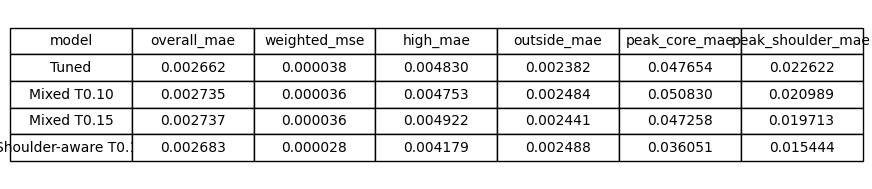

Saved PNG: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_shoulder_aware_targeted_evaluation/ct2dose_final_comparison_table_card30.png


In [24]:
fig, ax = plt.subplots(figsize=(11, 2.2))
ax.axis("off")

table = ax.table(
    cellText=final_comparison_fmt.values,
    colLabels=final_comparison_fmt.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

out_png = ANALYSIS_DIR / "ct2dose_final_comparison_table_card30.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()

print("Saved PNG:", out_png)